<span style="font-weight:bold; font-size: 3rem; color:#333;">- Part 04: Batch inference for Train Delay Data (Two-Stage Model)</span>

## 🗒️ Overview

This notebook downloads a stored model and uses it to perform batch inference.

It performs the following steps:

1. 


### 📝 Imports

In [13]:
# top of notebook
from features import (
    build_features,
    add_calendar_features,
    add_train_lag_features,
    add_station_network_state_features,
    detect_trigger_time,
    add_reactive_early_dynamics,
    add_weather_rolling_features_if_present,
    add_station_delay_features,
    ensure_event_time,
    add_cause_flags,
    add_station_congestion_features,
    build_duration_baseline,
)


In [14]:
import os
import datetime
import pandas as pd
import requests
#import hopsworks_utils
import datetime as dt
from dotenv import load_dotenv
#import hopsworks
from typing import Any, Dict, List, Optional, Tuple


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

True

## 📡 Connect to Hopsworks Feature Store

In [15]:
# Optional: Hopsworks storage (not required)
try:
    project = hopsworks_utils.HopsworksInterface()
    print("Hopsworks login OK")
except Exception as e:
    project = None
    print("Hopsworks not configured / login failed (OK). Proceeding without it.")
    print("Reason:", repr(e))

#train_feature_df = project.get("train_stop_events_labeled")

#uncoment the below line when weather features are stored
#weather_df = project.get("weather_features") 


Hopsworks not configured / login failed (OK). Proceeding without it.
Reason: NameError("name 'hopsworks_utils' is not defined")


In [16]:
import os
import json
import datetime as dt
from typing import Optional, Dict, Any, List

import numpy as np
import pandas as pd
import joblib


## 📥 Inputs

This notebook runs **batch inference** (no training) using:

- A **canonical events table**: `train_stop_events_labeled.parquet` (from Part 01), filtered to an inference window  
  *(or you can point to any new ops/events parquet with the same schema).*
- The **same feature engineering** as Part 02 (copied here to avoid train/serve skew).
- Trained model artifacts produced by Part 03.

**Output:** `predictions.parquet` / `predictions.csv` with:
- keys: `train_id`, `station_code`, `event_time`
- `risk_delay_soon` (calibrated if calibrator exists)
- `p50_delay`, `p90_delay` (post-trigger only)
- `outlook_status` = `PRE` / `POST`


In [17]:
import pandas as pd
import numpy as np
import datetime as dt
import os

# -----------------------------
# Configuration
# -----------------------------
CANONICAL_PATH = os.getenv("CANONICAL_PATH", "data/train_stop_events_labeled.parquet")

# Optional: restrict inference to a window (UTC naive timestamps).
INFER_START = os.getenv("INFER_START", "")  
INFER_END   = os.getenv("INFER_END", "")    
DEFAULT_LOOKBACK_DAYS = int(os.getenv("DEFAULT_LOOKBACK_DAYS", "7"))

HORIZON_MIN = int(os.getenv("HORIZON_MIN", "60"))
DELAY_THRESHOLD_MIN = int(os.getenv("DELAY_THRESHOLD_MIN", "10"))
# Rolling windows for network-state features
ROLL_WINDOWS_MIN = [1440, 1440*2]   # minutes
WEATHER_ROLL_WINDOWS_H = [3, 6]  # hours 
# -----------------------------
# 1. Load Data
# -----------------------------
if os.path.exists(CANONICAL_PATH):
    print(f"Loading data from {CANONICAL_PATH}...")
    df = pd.read_parquet(CANONICAL_PATH)
else:
    raise FileNotFoundError(f"Could not find input file at {CANONICAL_PATH}.")

# 2. Convert timestamps
if "event_time" in df.columns:
    df["event_time"] = pd.to_datetime(df["event_time"])

# 3. Filter Window (Batch Inference Logic)
if INFER_START and INFER_END:
    print(f"Filtering for window: {INFER_START} to {INFER_END}")
    mask = (df["event_time"] >= pd.to_datetime(INFER_START)) & (df["event_time"] < pd.to_datetime(INFER_END))
    df = df.loc[mask].copy()
else:
    print(f"No explicit window set. Selecting last {DEFAULT_LOOKBACK_DAYS} days.")
    max_time = df["event_time"].max()
    min_time = max_time - pd.Timedelta(days=DEFAULT_LOOKBACK_DAYS)
    df = df.loc[df["event_time"] >= min_time].copy()

print(f"✅ Data ready for inference. Rows: {len(df)}")

# -----------------------------
# 4. FIX: Rename & Print Weather
# -----------------------------
print("\n🔍 Checking for weather columns...")

# Map raw names to what features.py expects
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}

# Apply renaming
renamed_count = 0
for old_name, new_name in weather_rename_map.items():
    if old_name in df.columns:
        df.rename(columns={old_name: new_name}, inplace=True)
        renamed_count += 1

# Verify results
current_weather_cols = [c for c in df.columns if c.startswith("weather_")]

if current_weather_cols:
    print(f"✅ Success! Found and renamed {len(current_weather_cols)} weather columns.")
    print("Columns:", current_weather_cols)
    print("\nSample Weather Data:")
    display(df[current_weather_cols].head(5))
else:
    print("❌ WARNING: No weather columns found. Check if 'temperature_2m' etc. exist in the parquet file.")
    print("Available columns:", list(df.columns))

Loading data from data/train_stop_events_labeled.parquet...
No explicit window set. Selecting last 7 days.
✅ Data ready for inference. Rows: 69460

🔍 Checking for weather columns...
✅ Success! Found and renamed 6 weather columns.
Columns: ['weather_temperature_2m', 'weather_precipitation', 'weather_rain', 'weather_snowfall', 'weather_windspeed_10m', 'weather_time']

Sample Weather Data:


,weather_temperature_2m,weather_precipitation,weather_rain,weather_snowfall,weather_windspeed_10m,weather_time
0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00
1,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00
2,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00
3,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00
4,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00


## 🧱 Feature engineering (identical to Part 02)

In [18]:
# --- Feature Engineering Phase ---
# We use the shared logic from features.py to ensure 
# Training and Inference generate the exact same columns.

print("⚡️ Engineering features using 'features.py'...")

# 1. Clean & Rename (Safety Check)
# Ensure weather columns are named correctly before starting
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}
existing_rename = {k: v for k, v in weather_rename_map.items() if k in df.columns}
if existing_rename:
    df = df.rename(columns=existing_rename)

# 2. Build Features
# This one function call does ALL the math (Calendar, Lags, Rolling, Weather)
df_feat = build_features(df, WEATHER_ROLL_WINDOWS_H, ROLL_WINDOWS_MIN)

print("✅ Feature engineering complete.")
print("Feature table shape:", df_feat.shape)
display(df_feat.head())

⚡️ Engineering features using 'features.py'...
✅ Feature engineering complete.
Feature table shape: (69460, 64)


,event_time,ActivityId,ActivityType,train_id,scheduled_time,estimated_time,actual_time,observed_time,station_code,delay_min,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,2026-01-09 00:29:00+01:00,1500adde-075d-66fb-08de-4372b55866ce,Avgang,10994,2026-01-09 00:29:00+01:00,NaT,2026-01-09 00:31:00+01:00,2026-01-09 00:31:00+01:00,Arnc,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.888139
1,2026-01-09 00:29:00+01:00,1500adde-075d-66fb-08de-4372b55866cd,Ankomst,10994,2026-01-09 00:29:00+01:00,NaT,2026-01-09 00:29:00+01:00,2026-01-09 00:29:00+01:00,Arnc,0.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
2,2026-01-09 00:44:00+01:00,1500adde-075d-66fb-08de-4372fec1abda,Avgang,2285,2026-01-09 00:44:00+01:00,NaT,2026-01-09 00:44:00+01:00,2026-01-09 00:44:00+01:00,Arnc,0.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
3,2026-01-09 00:44:00+01:00,1500adde-075d-66fb-08de-4372fec1abd9,Ankomst,2285,2026-01-09 00:44:00+01:00,NaT,2026-01-09 00:42:00+01:00,2026-01-09 00:42:00+01:00,Arnc,-2.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
4,2026-01-09 04:44:00+01:00,1500adde-075d-66fb-08de-4372f5d3babf,Avgang,2205,2026-01-09 04:44:00+01:00,NaT,2026-01-09 04:46:00+01:00,2026-01-09 04:46:00+01:00,Arnc,2.0,...,NaN,NaN,NaN,NaN,-2.0,0.0,0.0,0.0,8.4,7.888139


In [19]:
import pandas as pd
import numpy as np
import os
from typing import Optional

def load_inference_events(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find inference dataset at: {path}")
    d = pd.read_parquet(path)
    if "event_time" not in d.columns:
        raise ValueError("Expected column 'event_time' in canonical dataset.")
    d["event_time"] = pd.to_datetime(d["event_time"], errors="coerce")
    d = d.dropna(subset=["event_time"]).copy()
    return d

def parse_ts(s: str) -> Optional[pd.Timestamp]:
    s = (s or "").strip()
    if not s:
        return None
    return pd.to_datetime(s, errors="raise")

# 1. Load Data
events = load_inference_events(CANONICAL_PATH)

# --- CRITICAL FIX: RENAME WEATHER COLUMNS ---
# This ensures features.py can find them later
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}
# Only rename if they exist (safe check)
existing_rename = {k: v for k, v in weather_rename_map.items() if k in events.columns}
if existing_rename:
    print(f"🔄 Renaming {len(existing_rename)} weather columns for consistency.")
    events = events.rename(columns=existing_rename)
# ---------------------------------------------

# 2. Filter to inference window
start_ts = parse_ts(INFER_START)
end_ts = parse_ts(INFER_END)

if start_ts is not None:
    events = events[events["event_time"] >= start_ts]
if end_ts is not None:
    events = events[events["event_time"] < end_ts]

if start_ts is None and end_ts is None:
    # default: last DEFAULT_LOOKBACK_DAYS present in data
    max_t = events["event_time"].max()
    min_t = max_t - pd.Timedelta(days=DEFAULT_LOOKBACK_DAYS)
    events = events[events["event_time"] >= min_t]
    print(f"No INFER_START/INFER_END set -> using last {DEFAULT_LOOKBACK_DAYS} days: {min_t} → {max_t}")

events = events.sort_values(["event_time", "station_code", "train_id"]).reset_index(drop=True)
print("Inference rows:", len(events))

# 3. Verify Weather Columns exist
w_cols = [c for c in events.columns if "weather_" in c]
print(f"✅ Active Weather Columns: {w_cols}")

display(events.head())

🔄 Renaming 5 weather columns for consistency.
No INFER_START/INFER_END set -> using last 7 days: 2026-01-05 11:53:00+01:00 → 2026-01-12 11:53:00+01:00
Inference rows: 69460
✅ Active Weather Columns: ['weather_temperature_2m', 'weather_precipitation', 'weather_rain', 'weather_snowfall', 'weather_windspeed_10m', 'weather_time']


,ActivityId,ActivityType,train_id,event_time,scheduled_time,estimated_time,actual_time,observed_time,station_code,delay_min,...,final_delay_min,additional_delay_min,y_delay_within_horizon,weather_temperature_2m,weather_precipitation,weather_rain,weather_snowfall,weather_windspeed_10m,weather_time,source
0,1500adde-075d-66fb-08de-437328465cb5,Avgang,2983,2026-01-09 00:00:00+01:00,2026-01-09 00:00:00+01:00,NaT,2026-01-09 00:00:00+01:00,2026-01-09 00:00:00+01:00,Mr,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00,archive
1,1500adde-075d-66fb-08de-4373071fa14a,Avgang,2477,2026-01-09 00:03:00+01:00,2026-01-09 00:03:00+01:00,NaT,2026-01-09 00:03:00+01:00,2026-01-09 00:03:00+01:00,Söc,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00,archive
2,1500adde-075d-66fb-08de-437328465cb7,Avgang,2983,2026-01-09 00:04:00+01:00,2026-01-09 00:04:00+01:00,NaT,2026-01-09 00:04:00+01:00,2026-01-09 00:04:00+01:00,Rs,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00,archive
3,1500adde-075d-66fb-08de-437328465cb6,Ankomst,2983,2026-01-09 00:04:00+01:00,2026-01-09 00:04:00+01:00,NaT,2026-01-09 00:03:00+01:00,2026-01-09 00:03:00+01:00,Rs,-1.0,...,0.0,1.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00,archive
4,1500adde-075d-66fb-08de-437353752403,Avgang,7879,2026-01-09 00:05:00+01:00,2026-01-09 00:05:00+01:00,NaT,2026-01-09 00:05:00+01:00,2026-01-09 00:05:00+01:00,Arnn,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-09 00:00:00+01:00,archive


## 🧮 Build model-ready features (no leakage)

In [20]:
import json

FEATURE_METADATA_PATH = "data/feature_pipeline_outputs/feature_metadata.json"
# --- 1. Load Feature Metadata (The "Contract" from Part 2) ---
# We need to know EXACTLY which columns the model expects.
if os.path.exists(FEATURE_METADATA_PATH):
    with open(FEATURE_METADATA_PATH, "r") as f:
        meta = json.load(f)
        # These are the lists of columns we saved in Part 2
        pred_cols = meta["pred_feature_columns"]
        react_cols = meta["react_feature_columns"]
    print(f"✅ Loaded feature lists from metadata.")
    print(f"   Predictive features: {len(pred_cols)}")
    print(f"   Reactive features:   {len(react_cols)}")
else:
    raise FileNotFoundError(f"Could not find metadata at {FEATURE_METADATA_PATH}. Did Part 2 run successfully?")

# --- 2. Feature Selection Functions ---

def build_pred_dataset(df_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Prepares dataset for Predictive Model.
    SAFETY: Selects ONLY the columns used in training. 
    Drops IDs, Targets (delay_min), and Dates to prevent leakage.
    """
    # Ensure all expected columns exist (fill missing with 0 if necessary)
    # This handles edge cases where a feature might be missing in a small batch
    missing = [c for c in pred_cols if c not in df_feat.columns]
    if missing:
        print(f"⚠️ Warning: Missing columns filled with 0: {missing}")
        for c in missing:
            df_feat[c] = 0
            
    # Return exactly the columns the model was trained on
    return df_feat[pred_cols].copy()

def build_react_dataset(df_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Prepares dataset for Reactive Model.
    Filter: Only trains that are ALREADY delayed.
    """
    mask = df_feat["delay_min"] >= DELAY_THRESHOLD_MIN
    df_filtered = df_feat.loc[mask].copy()
    
    # Ensure columns exist
    missing = [c for c in react_cols if c not in df_filtered.columns]
    if missing:
        for c in missing:
            df_filtered[c] = 0
            
    return df_filtered[react_cols].copy()

print("✅ Feature selection logic ready.")

✅ Loaded feature lists from metadata.
   Predictive features: 48
   Reactive features:   50
✅ Feature selection logic ready.


In [21]:
# Assuming 'df_feat' is your engineered dataframe from the previous step:
events = df_feat 

# Build *predictive* feature table
pred_ds = build_pred_dataset(events)

# Build *reactive* feature table (post-trigger subset)
react_ds = build_react_dataset(events)

print("pred_ds shape:", pred_ds.shape)
print("react_ds shape:", react_ds.shape)
display(pred_ds.head())


⚠️ Warning: Missing columns filled with 0: ['roll_mean_delay_station_15m', 'roll_cnt_delay_ge_10_station_15m', 'roll_mean_delay_station_30m', 'roll_cnt_delay_ge_10_station_30m']


pred_ds shape: (69460, 48)
react_ds shape: (3700, 50)


,ActivityType,delay_min,is_canceled,Deleted,Deviation,FromLocation,ToLocation,TrackAtLocation,hour,dow,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,Avgang,2.0,False,False,None,Cst,"Kn,U",1,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.888139
1,Ankomst,0.0,False,False,None,Cst,U,1,0,4,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
2,Avgang,0.0,False,False,Kort tåg,U,Sci,2,0,4,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
3,Ankomst,-2.0,False,False,None,U,Sci,2,0,4,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.888139
4,Avgang,2.0,False,False,None,U,"Sci,Söc",2,4,4,...,NaN,NaN,NaN,NaN,-2.0,0.0,0.0,0.0,8.4,7.888139


## 🤖 Load models (from Part 03)

In [22]:
PRED_MODEL_PATH = "data/models/predictive_model.pkl"
CALIBRATOR_PATH = "data/models/calibrator.pkl"
REACT_MODEL_PATH = "data/models/reactive_model.pkl"
if not os.path.exists(PRED_MODEL_PATH):
    raise FileNotFoundError(
        f"Missing predictive model at {PRED_MODEL_PATH}. Run 3_train_training_pipeline first."
    )
pred_model = joblib.load(PRED_MODEL_PATH)

calibrator = None
if os.path.exists(CALIBRATOR_PATH):
    calibrator = joblib.load(CALIBRATOR_PATH)
    print("Loaded calibrator:", CALIBRATOR_PATH)
else:
    print("No calibrator found (ok). Will use raw model probabilities.")

if not os.path.exists(REACT_MODEL_PATH):
    raise FileNotFoundError(
        f"Missing reactive model at {REACT_MODEL_PATH}. Run 3_train_training_pipeline first."
    )
react_bundle = joblib.load(REACT_MODEL_PATH)

# Expect react_bundle to contain quantile models if you trained them:
# { "point": model, "q10": model, "q50": model, "q90": model } OR similar.
print("Reactive bundle keys:", list(react_bundle.keys()) if isinstance(react_bundle, dict) else type(react_bundle))


Loaded calibrator: data/models/calibrator.pkl
Reactive bundle keys: ['point', 'q10', 'q50', 'q90', 'target']


In [23]:
import numpy as np
import pandas as pd



# ------------------------------------------------------------------
# 0) Define ID columns for output
# ------------------------------------------------------------------
id_cols = ["ActivityId", "train_id", "station_code"]

# Carry these along if they exist (helps early-warning filtering + debugging)
extra_cols = [c for c in ["delay_min", "min_since_trigger", "event_time"] if c in events.columns]

# ------------------------------------------------------------------
# 1) Build base table with IDs (+ extras) from events
#    Attach engineered features from pred_ds by row alignment
# ------------------------------------------------------------------
base = events[id_cols + extra_cols].copy().reset_index(drop=True)

# Drop any IDs/extras from pred_ds to avoid duplicate columns after concat
pred_feats = pred_ds.drop(columns=id_cols + extra_cols, errors="ignore").copy().reset_index(drop=True)

# Defensive: same length check
if len(base) != len(pred_feats):
    raise RuntimeError(
        f"Length mismatch: events has {len(base)} rows, pred_ds has {len(pred_feats)} rows. "
        "You need a real join key (e.g., ActivityId) carried inside pred_ds."
    )

pred_ds_full = pd.concat([base, pred_feats], axis=1)

# sanity: ensure no duplicate columns
dups = pred_ds_full.columns[pred_ds_full.columns.duplicated()].tolist()
if dups:
    raise RuntimeError(f"Duplicate columns detected after concat: {dups}")

# ------------------------------------------------------------------
# 2) Build X_pred with EXACT columns expected by the trained pipeline
# ------------------------------------------------------------------
model_for_cols = (
    calibrator if (calibrator is not None and hasattr(calibrator, "feature_names_in_"))
    else pred_model
)

if not hasattr(model_for_cols, "feature_names_in_"):
    raise RuntimeError("Cannot infer required feature columns from model.")

required_cols = list(model_for_cols.feature_names_in_)
X_pred = pred_ds_full.reindex(columns=required_cols)

# ------------------------------------------------------------------
# 3) CRITICAL SANITIZATION STEP
# ------------------------------------------------------------------
for c in X_pred.columns:
    if pd.api.types.is_datetime64_any_dtype(X_pred[c]):
        X_pred[c] = (X_pred[c].view("int64") / 1e9).astype(float)
        X_pred[c] = X_pred[c].fillna(0.0)
        continue

    if X_pred[c].dtype == "object" and ("time" in c.lower()):
        parsed = pd.to_datetime(X_pred[c], errors="coerce")
        if parsed.notna().any():
            X_pred[c] = (parsed.view("int64") / 1e9).astype(float)
            X_pred[c] = X_pred[c].fillna(0.0)
            continue

    if pd.api.types.is_numeric_dtype(X_pred[c]) or pd.api.types.is_bool_dtype(X_pred[c]):
        X_pred[c] = X_pred[c].astype(float).fillna(0.0)
    else:
        X_pred[c] = X_pred[c].apply(lambda x: "" if pd.isna(x) else str(x))


In [24]:
from features import ensure_event_time, add_station_congestion_features




events = df_feat.copy()

# (Optional but recommended) choose WHICH time defines "history"
# If you want scheduled_time as your reference:
# events["event_time"] = events["scheduled_time"]

events = ensure_event_time(events)

# IMPORTANT: include the windows your model expects
events = add_station_congestion_features(events, windows_min=[15, 30])

# Now build datasets
pred_ds  = build_pred_dataset(events)
react_ds = build_react_dataset(events)

print(pred_ds[[
    "roll_mean_delay_station_15m",
    "roll_cnt_delay_ge_10_station_15m",
    "roll_mean_delay_station_30m",
    "roll_cnt_delay_ge_10_station_30m",
]].describe().T)

roll_cols = [
    "roll_mean_delay_station_15m",
    "roll_cnt_delay_ge_10_station_15m",
    "roll_mean_delay_station_30m",
    "roll_cnt_delay_ge_10_station_30m",
]

events[roll_cols] = events[roll_cols].fillna(0.0)
X_pred[roll_cols].isna().mean()


                                    count      mean       std        min  \
roll_mean_delay_station_15m       46203.0  2.595941  5.781240 -20.847154   
roll_cnt_delay_ge_10_station_15m  46203.0  0.527953  1.168007   0.000000   
roll_mean_delay_station_30m       48277.0  2.530948  5.035565  -9.000000   
roll_cnt_delay_ge_10_station_30m  48277.0  0.987634  2.003640   0.000000   

                                       25%  50%   75%    max  
roll_mean_delay_station_15m      -0.250000  0.5  2.75  125.0  
roll_cnt_delay_ge_10_station_15m  0.000000  0.0  0.00   12.0  
roll_mean_delay_station_30m      -0.153846  0.6  2.90   81.0  
roll_cnt_delay_ge_10_station_30m  0.000000  0.0  1.00   17.0  


roll_mean_delay_station_15m         0.0
roll_cnt_delay_ge_10_station_15m    0.0
roll_mean_delay_station_30m         0.0
roll_cnt_delay_ge_10_station_30m    0.0
dtype: float64

In [32]:
print("Predicting...")
# ------------------------------------------------------------------
# 4) Predict calibrated risk
# ------------------------------------------------------------------
if calibrator is not None and hasattr(calibrator, "predict_proba"):
    risk = calibrator.predict_proba(X_pred)[:, 1]
else:
    risk = pred_model.predict_proba(X_pred)[:, 1]

# ------------------------------------------------------------------
# 5) Build outputs: FULL + EARLY-WARNING ONLY
# ------------------------------------------------------------------
out_full = pred_ds_full[id_cols + extra_cols].copy()
out_full["risk_delay_soon"] = risk

# Ensure consistent grouping keys
out_full["train_id"] = out_full["train_id"].astype(str)
out_full["station_code"] = out_full["station_code"].astype(str)

# Early-warning filter:
# Prefer pre-trigger if available; otherwise use "not already delayed"
if "min_since_trigger" in out_full.columns:
    out_early = out_full[out_full["min_since_trigger"] < 0].copy()
elif "delay_min" in out_full.columns:
    out_early = out_full[out_full["delay_min"] < 10].copy()
else:
    # fallback: can't filter; return full
    out_early = out_full.copy()

# ------------------------------------------------------------------
# 6) Save outputs
# ------------------------------------------------------------------
out_full_path_parquet = "data/predictions_full.parquet"
out_full_path_csv     = "data/predictions_full.csv"
out_early_path_parquet = "data/predictions_early.parquet"
out_early_path_csv     = "data/predictions_early.csv"

out_full.to_parquet(out_full_path_parquet, index=False)
out_full.to_csv(out_full_path_csv, index=False)
out_early.to_parquet(out_early_path_parquet, index=False)
out_early.to_csv(out_early_path_csv, index=False)

print("✅ Saved predictions:")
print(out_full_path_parquet)
print(out_full_path_csv)
print(out_early_path_parquet)
print(out_early_path_csv)

# Show top-20 EARLY warnings (not already delayed)
out_early = out_early.sort_values("risk_delay_soon", ascending=False)
display(out_early.head(20))

#Filter out future train departures

#print(out_early.info())
#out_early["event_time"] = pd.to_datetime(out_early["event_time"], errors="coerce")
#future_pred = out_early[out_early["event_time"] > pd.Timestamp.now()]

# ------------------------------------------------------------------
# 7) Average risk per station/train (EARLY set)
# ------------------------------------------------------------------
station_avg_risk_early = (
    out_early.groupby("station_code")["risk_delay_soon"]
            .mean()
            .sort_values(ascending=False)
            .rename("station_avg_risk_early")
)

train_avg_risk_early = (
    out_early.groupby("train_id")["risk_delay_soon"]
            .mean()
            .sort_values(ascending=False)
            .rename("train_avg_risk_early")
)

display(station_avg_risk_early.head(20))
display(train_avg_risk_early.head(20))

# Optional: quick sanity stats
print("Early rows:", len(out_early), "/", len(out_full))
print("Share early risk ~1.0:", (out_early["risk_delay_soon"] >= 0.999).mean() if len(out_early) else np.nan)


Predicting...
✅ Saved predictions:
data/predictions_full.parquet
data/predictions_full.csv
data/predictions_early.parquet
data/predictions_early.csv


,ActivityId,train_id,station_code,delay_min,min_since_trigger,event_time,risk_delay_soon
28744,1500adde-075d-66fb-08de-45074cc41046,2986,Rs,2.0,-9999.0,2026-01-11 02:26:00+01:00,1.000000
55749,1500adde-075d-66fb-08de-4373426de8c2,585,U,2.0,-20.0,2026-01-09 19:59:00+01:00,0.910983
24424,1500adde-075d-66fb-08de-443d2ad016be,2544,Ngd,0.0,-46.0,2026-01-10 14:23:00+01:00,0.882353
51602,1500adde-075d-66fb-08de-443d2ad016c5,2544,Ts,2.0,-27.0,2026-01-10 14:42:00+01:00,0.882353
68079,1500adde-075d-66fb-08de-443d2ad016c0,2544,Öso,2.0,-39.0,2026-01-10 14:30:00+01:00,0.882353
12169,1500adde-075d-66fb-08de-443d4460ffa2,2976,Hel,6.0,-3.0,2026-01-10 23:36:00+01:00,0.882353
10767,1500adde-075d-66fb-08de-443d2acdb479,2544,Gdv,1.0,-49.0,2026-01-10 14:20:00+01:00,0.882353
26554,1500adde-075d-66fb-08de-443d2acdb477,2544,Nyc,0.0,-51.0,2026-01-10 14:18:00+01:00,0.882353
51601,1500adde-075d-66fb-08de-443d2ad016c6,2544,Ts,3.0,-27.0,2026-01-10 14:42:00+01:00,0.882353
44477,1500adde-075d-66fb-08de-443d2ad016c2,2544,Ssä,2.0,-35.0,2026-01-10 14:34:00+01:00,0.882353


station_code
Nyc     0.010756
Cst     0.007344
Öso     0.007238
Ssä     0.006966
Ts      0.006910
Kda     0.006910
Hfa     0.006884
Gdv     0.006870
Ngd     0.006868
U       0.006308
Rs      0.005068
Hu      0.004717
Sta     0.004426
Mr      0.004214
Tbo     0.004151
Hel     0.004108
Vhd     0.004088
Söu     0.003884
Arnc    0.003828
So      0.003758
Name: station_avg_risk_early, dtype: float64

train_id
585      0.245603
2544     0.124701
10994    0.057586
7807     0.044953
7909     0.044944
7907     0.044170
7805     0.044170
7905     0.044077
7903     0.043984
7803     0.043984
71       0.039978
10       0.034090
7900     0.027362
906      0.026551
166      0.024683
546      0.023810
450      0.023810
448      0.023810
2761     0.023810
442      0.023810
Name: train_avg_risk_early, dtype: float64

Early rows: 65015 / 69460
Share early risk ~1.0: 1.5381065907867414e-05


In [26]:
tmp = pred_ds_full.copy()
tmp["risk"] = risk

hi = tmp[tmp["risk"] >= 0.999]

cols = [c for c in [
    "event_time", "ActivityType", "delay_min", "reason_code",
    "trigger_time", "min_since_trigger", "is_first15m_after_trigger"
] if c in hi.columns]

display(hi[cols].head(30))

# How many high-risk are already delayed / post-trigger?
stats = {}
if "delay_min" in tmp.columns:
    stats["hi_delay_ge_10"] = (hi["delay_min"] >= 10).mean()
if "min_since_trigger" in tmp.columns:
    stats["hi_post_trigger"] = (hi["min_since_trigger"] >= 0).mean()
if "reason_code" in tmp.columns:
    stats["hi_has_reason_code"] = hi["reason_code"].notna().mean()

stats


,event_time,ActivityType,delay_min,min_since_trigger
578,2026-01-10 17:54:00+01:00,Avgang,69.0,19.0
5964,2026-01-09 22:47:00+01:00,Ankomst,15.0,0.0
6577,2026-01-11 09:44:00+01:00,Ankomst,21.0,27.0
6640,2026-01-11 11:58:00+01:00,Ankomst,125.0,12.0
6662,2026-01-11 12:40:00+01:00,Ankomst,69.0,20.0
7307,2026-01-09 07:01:00+01:00,Ankomst,18.0,31.0
14170,2026-01-10 23:42:00+01:00,Ankomst,8.0,3.0
28744,2026-01-11 02:26:00+01:00,Avgang,2.0,-9999.0
56014,2026-01-10 17:35:00+01:00,Ankomst,67.0,0.0
57464,2026-01-10 23:42:00+01:00,Ankomst,12.0,1422.0


{'hi_delay_ge_10': 0.8, 'hi_post_trigger': 0.9}

<Figure size 1000x1000 with 0 Axes>

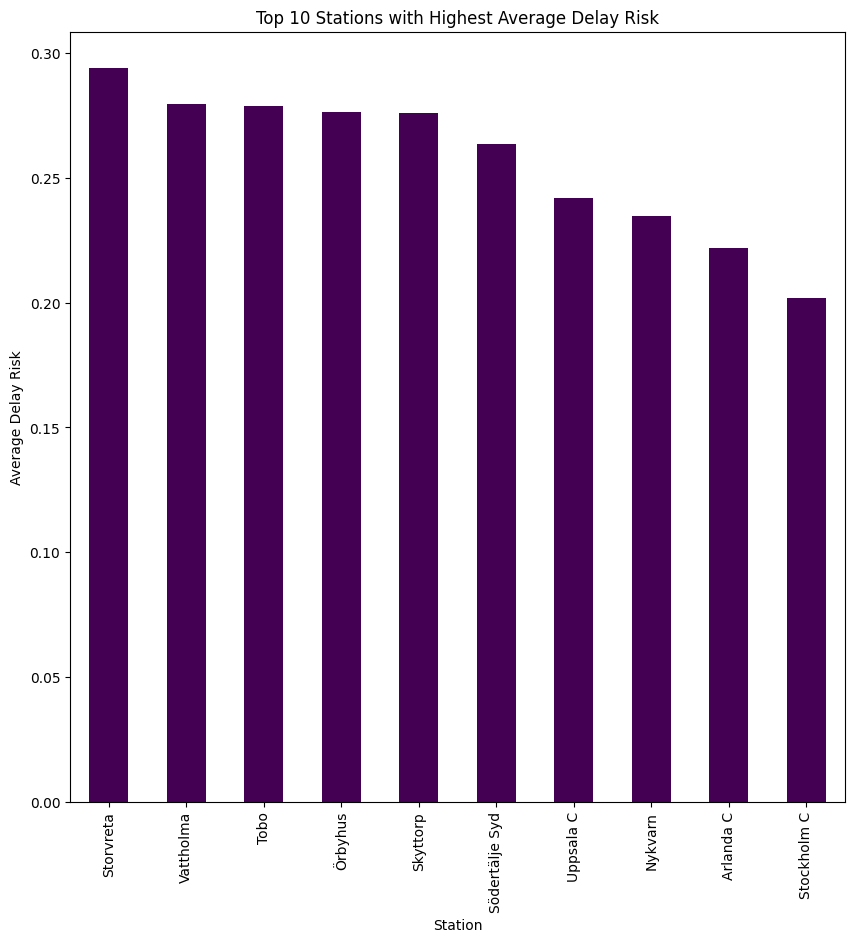

In [33]:
import pandas as pd
from typing import Any, Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point


station_avg_risk = pd.read_parquet("data/station_avg_risk.parquet")
station_df = pd.read_parquet("data/station_features.parquet")


# Merge station_avg_risk with coordinates from station_df

station_df.rename(columns={"LocationSignature": "station_code"}, inplace=True)


res = station_avg_risk.set_index("station_code").join(station_df.set_index("station_code"), on=["station_code"])


# Create geometry
geometry = [
    Point(lon, lat) for lon, lat in zip(res["lon"], res["lat"])
]

gdf = gpd.GeoDataFrame(res, geometry=geometry, crs="EPSG:4326")

gdf = gdf.to_crs(epsg=3857)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="station_avg_risk",
    cmap="viridis",
    vmin=0,
    vmax=1,
    legend=True,
    legend_kwds={"label": "Predicted value"},
    markersize=50,
    alpha=0.9
)


ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)
ax.set_title("Predicted values per train station (Stockholm)")
ax.axis("off")

plt.savefig("docs/assets/img/station_delay_risk_map.png")
plt.clf()
# Bar chart of top 10 stations with highest average risk
top10 = res.sort_values("station_avg_risk", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 10))
top10.plot(
    ax=ax,
    kind="bar",
    x="AdvertisedLocationName",
    y="station_avg_risk",
    #color="station_avg_risk",
    cmap="viridis",
    legend=False
)
ax.set_title("Top 10 Stations with Highest Average Delay Risk")
ax.set_xlabel("Station")
ax.set_ylabel("Average Delay Risk")
plt.savefig("docs/assets/img/top10_station_delay_risk.png")
